# 03 - EDA: Variância Intra-H2 e Qualidade do Mapeamento skill → H2

## Motivação

Os modelos Topic H2 (DKT e LPKT) operam colapsando skills folha em tópicos de nível 2 da hierarquia de assuntos. 
Esse colapso pode introduzir ruído no sinal de treino caso **skills muito diferentes em dificuldade estejam agrupadas no mesmo H2**.

Este notebook investiga:

1. **Cobertura do mapeamento** — quantas skills e interações são perdidas no colapso H2
2. **Estrutura dos grupos H2** — quantas skills por tópico, concentração
3. **Variância intra-H2** — heterogeneidade de dificuldade dentro de cada tópico H2
4. **Comparação de granularidade** — skill-level vs H2-level como proxy de dificuldade
5. **Impacto no sinal de treino** — estimativa de ruído introduzido pelo colapso
6. **Conclusão e recomendações** — validar ou refutar a hipótese de ruído intra-H2


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

ANSWERS_PATH  = PROJECT_ROOT / 'data' / 'processed' / 'dataset'   / 'answers_prepared.csv'
H2_MAP_PATH   = PROJECT_ROOT / 'data' / 'processed' / 'mappings'  / 'skill_to_h2.json'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Paths OK:', ANSWERS_PATH.exists(), H2_MAP_PATH.exists())

Paths OK: True True


## 1. Carregamento dos dados

In [2]:
answers = pd.read_csv(ANSWERS_PATH, dtype={'user_id': str, 'question_id': str, 'skill_id': str})
answers['correct'] = answers['correct'].astype(int)

with open(H2_MAP_PATH, encoding='utf-8') as f:
    skill_to_h2: dict[str, str] = json.load(f)

answers['h2'] = answers['skill_id'].map(skill_to_h2)

print(f'Respostas totais : {len(answers):,}')
print(f'Usuários         : {answers["user_id"].nunique():,}')
print(f'Skills únicas    : {answers["skill_id"].nunique():,}')
print(f'H2 mapeados      : {answers["h2"].nunique():,}')
print(f'Interações com H2: {answers["h2"].notna().sum():,} ({answers["h2"].notna().mean():.1%})')
print(f'Interações sem H2: {answers["h2"].isna().sum():,} ({answers["h2"].isna().mean():.1%})')

Respostas totais : 539,486
Usuários         : 1,173
Skills únicas    : 441
H2 mapeados      : 45
Interações com H2: 539,379 (100.0%)
Interações sem H2: 107 (0.0%)


## 2. Cobertura do mapeamento skill → H2

Antes de analisar a qualidade do agrupamento, precisamos entender **o que é perdido** quando colapsamos skills em H2.

In [3]:
all_skills = set(answers['skill_id'].unique())
mapped_skills = set(skill_to_h2.keys())
unmapped_skills = all_skills - mapped_skills

coverage_df = pd.DataFrame({
    'Métrica': [
        'Skills no dataset',
        'Skills com H2 mapeado',
        'Skills sem H2 (perdidas)',
        'Interações cobertas por H2',
        'Interações perdidas (sem H2)',
    ],
    'Valor': [
        len(all_skills),
        len(mapped_skills & all_skills),
        len(unmapped_skills),
        answers['h2'].notna().sum(),
        answers['h2'].isna().sum(),
    ],
    '%': [
        100.0,
        100 * len(mapped_skills & all_skills) / len(all_skills),
        100 * len(unmapped_skills) / len(all_skills),
        100 * answers['h2'].notna().mean(),
        100 * answers['h2'].isna().mean(),
    ]
})
coverage_df['%'] = coverage_df['%'].map('{:.1f}%'.format)
display(coverage_df.to_string(index=False))

# Skills sem mapeamento: quais são as mais frequentes?
unmapped_counts = answers[answers['h2'].isna()]['skill_id'].value_counts().head(10)
print('\nTop 10 skills sem H2 (por frequência):')
display(unmapped_counts)

'                     Métrica  Valor      %\n           Skills no dataset    441 100.0%\n       Skills com H2 mapeado    435  98.6%\n    Skills sem H2 (perdidas)      6   1.4%\n  Interações cobertas por H2 539379 100.0%\nInterações perdidas (sem H2)    107   0.0%'


Top 10 skills sem H2 (por frequência):


skill_id
0edb28c4-9b65-4f02-bdf4-e4f76fbd5aab    33
8545de7b-9050-46a1-a2ef-74a974f1bacc    22
a92d71a1-625c-478d-8232-beff126686d2    20
c9e773ad-43b8-4e77-ad94-eca83400f3e3    18
b69cd7fc-2e07-4d53-ad22-3782ec8a677d    13
a0329b07-d6d6-4573-a084-2a46088fef2a     1
Name: count, dtype: int64

## 3. Estrutura dos grupos H2

Quantas skills existem por tópico H2? Um H2 com muitas skills heterogêneas é candidato a introduzir ruído.

Distribuição de skills por H2:
count    45.0
mean      9.7
std      10.3
min       1.0
25%       1.0
50%       5.0
75%      15.0
90%      26.2
max      37.0
Name: skill_id, dtype: float64


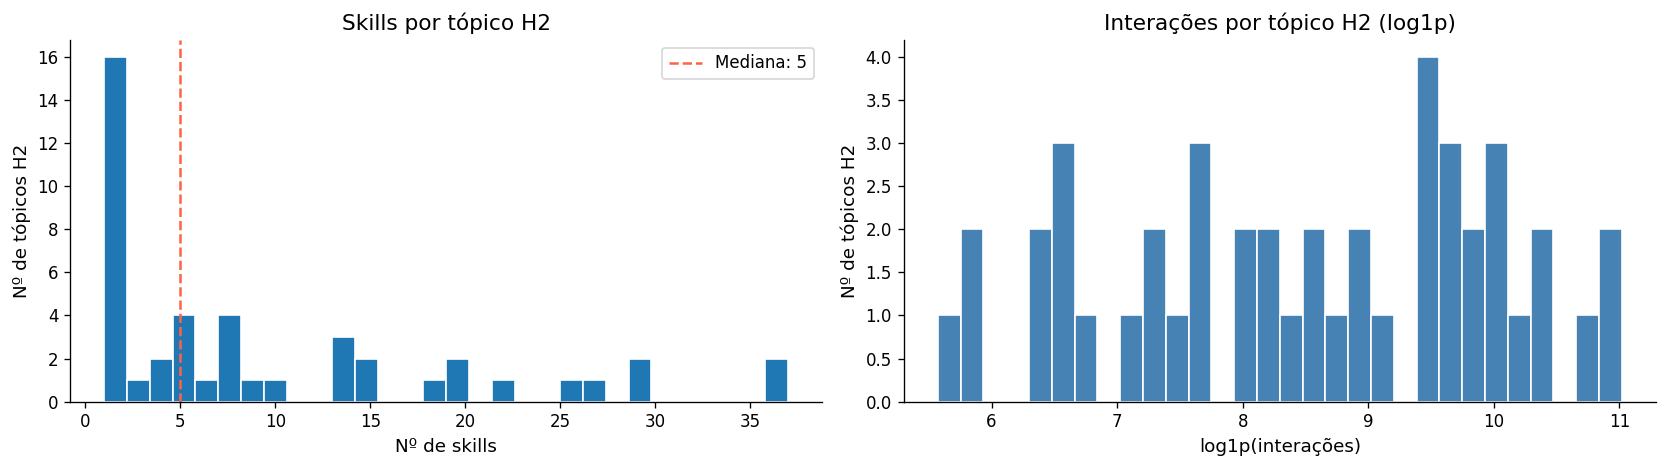


H2 com mais skills: {'Cirurgia > Cirurgia geral': 37, 'Ginecologia e Obstetrícia > Obstetrícia': 37, 'Ginecologia e Obstetrícia > Ginecologia': 29, 'Cirurgia > Especialidades cirúrgicas': 29, 'Cirurgia > Gastroenterologia': 27}


In [4]:
# Skills por H2
skills_per_h2 = (
    answers.dropna(subset=['h2'])
    .groupby('h2')['skill_id']
    .nunique()
    .sort_values(ascending=False)
)

# Interações por H2
interactions_per_h2 = (
    answers.dropna(subset=['h2'])
    .groupby('h2')
    .size()
    .sort_values(ascending=False)
)

print('Distribuição de skills por H2:')
print(skills_per_h2.describe(percentiles=[.25, .5, .75, .9]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(skills_per_h2, bins=30, edgecolor='white')
axes[0].set_title('Skills por tópico H2')
axes[0].set_xlabel('Nº de skills')
axes[0].set_ylabel('Nº de tópicos H2')
axes[0].axvline(skills_per_h2.median(), color='tomato', linestyle='--', label=f'Mediana: {skills_per_h2.median():.0f}')
axes[0].legend()

axes[1].hist(np.log1p(interactions_per_h2), bins=30, edgecolor='white', color='steelblue')
axes[1].set_title('Interações por tópico H2 (log1p)')
axes[1].set_xlabel('log1p(interações)')
axes[1].set_ylabel('Nº de tópicos H2')

plt.tight_layout()
plt.show()

print(f'\nH2 com mais skills: {skills_per_h2.head(5).to_dict()}')

## 4. Taxa de acerto: skill-level vs H2-level

Comparamos a distribuição de dificuldade quando medida por skill individual versus por tópico H2.
Se o H2 suaviza demais, os modelos perdem o sinal de dificuldade específica.

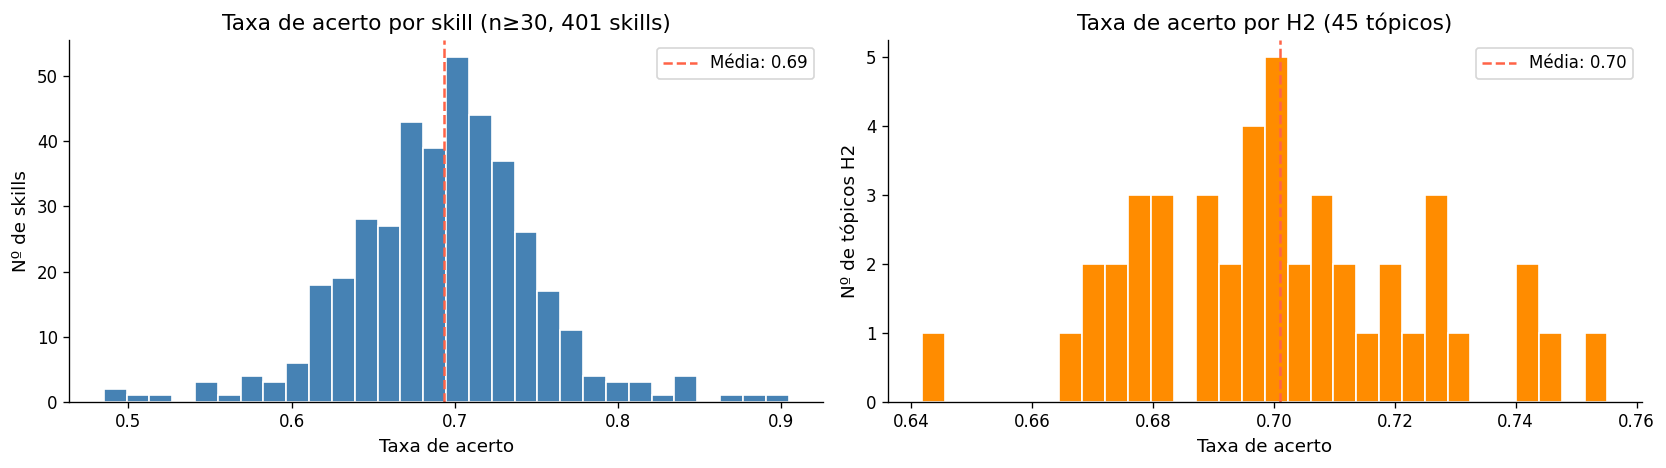

Std de acerto por skill : 0.0562
Std de acerto por H2    : 0.0234
Compressão de variância : 58.3%


In [5]:
# Taxa de acerto por skill
skill_acc = (
    answers.groupby('skill_id')['correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n'})
)
# Filtra skills com >= 30 interações para evitar ruído amostral
skill_acc_filtered = skill_acc[skill_acc['n'] >= 30]

# Taxa de acerto por H2
h2_acc = (
    answers.dropna(subset=['h2'])
    .groupby('h2')['correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(skill_acc_filtered['accuracy'], bins=30, edgecolor='white', color='steelblue')
axes[0].set_title(f'Taxa de acerto por skill (n≥30, {len(skill_acc_filtered)} skills)')
axes[0].set_xlabel('Taxa de acerto')
axes[0].set_ylabel('Nº de skills')
axes[0].axvline(skill_acc_filtered['accuracy'].mean(), color='tomato', linestyle='--',
                label=f'Média: {skill_acc_filtered["accuracy"].mean():.2f}')
axes[0].legend()

axes[1].hist(h2_acc['accuracy'], bins=30, edgecolor='white', color='darkorange')
axes[1].set_title(f'Taxa de acerto por H2 ({len(h2_acc)} tópicos)')
axes[1].set_xlabel('Taxa de acerto')
axes[1].set_ylabel('Nº de tópicos H2')
axes[1].axvline(h2_acc['accuracy'].mean(), color='tomato', linestyle='--',
                label=f'Média: {h2_acc["accuracy"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Std de acerto por skill : {skill_acc_filtered["accuracy"].std():.4f}')
print(f'Std de acerto por H2    : {h2_acc["accuracy"].std():.4f}')
print(f'Compressão de variância : {1 - h2_acc["accuracy"].std() / skill_acc_filtered["accuracy"].std():.1%}')

## 5. Variância intra-H2

Para cada tópico H2, calculamos o **desvio padrão das taxas de acerto das skills que o compõem**.
Alto desvio intra-H2 significa que skills muito diferentes de dificuldade estão sendo tratadas como equivalentes pelo modelo.

In [6]:
# Acerto por skill (com n mínimo)
skill_acc_with_h2 = skill_acc_filtered.copy()
skill_acc_with_h2['h2'] = skill_acc_with_h2.index.map(skill_to_h2)
skill_acc_with_h2 = skill_acc_with_h2.dropna(subset=['h2'])

# Variância intra-H2: desvio padrão da accuracy das skills dentro de cada H2
intra_h2_stats = (
    skill_acc_with_h2.groupby('h2')['accuracy']
    .agg(['mean', 'std', 'count', 'min', 'max'])
    .rename(columns={'mean': 'h2_mean_acc', 'std': 'intra_std', 'count': 'n_skills',
                     'min': 'min_acc', 'max': 'max_acc'})
)
intra_h2_stats['range'] = intra_h2_stats['max_acc'] - intra_h2_stats['min_acc']
intra_h2_stats['intra_std'] = intra_h2_stats['intra_std'].fillna(0)

print('Estatísticas de variância intra-H2 (por tópico):')
print(intra_h2_stats[['n_skills', 'h2_mean_acc', 'intra_std', 'range']]
      .describe(percentiles=[.25, .5, .75, .9])
      .round(4))

Estatísticas de variância intra-H2 (por tópico):
       n_skills  h2_mean_acc  intra_std    range
count   45.0000      45.0000    45.0000  45.0000
mean     8.8889       0.6995     0.0320   0.1063
std      9.3644       0.0249     0.0263   0.0982
min      1.0000       0.6578     0.0000   0.0000
25%      1.0000       0.6822     0.0000   0.0000
50%      5.0000       0.6978     0.0395   0.1010
75%     14.0000       0.7147     0.0512   0.1636
90%     22.0000       0.7346     0.0658   0.2557
max     35.0000       0.7552     0.0817   0.3296


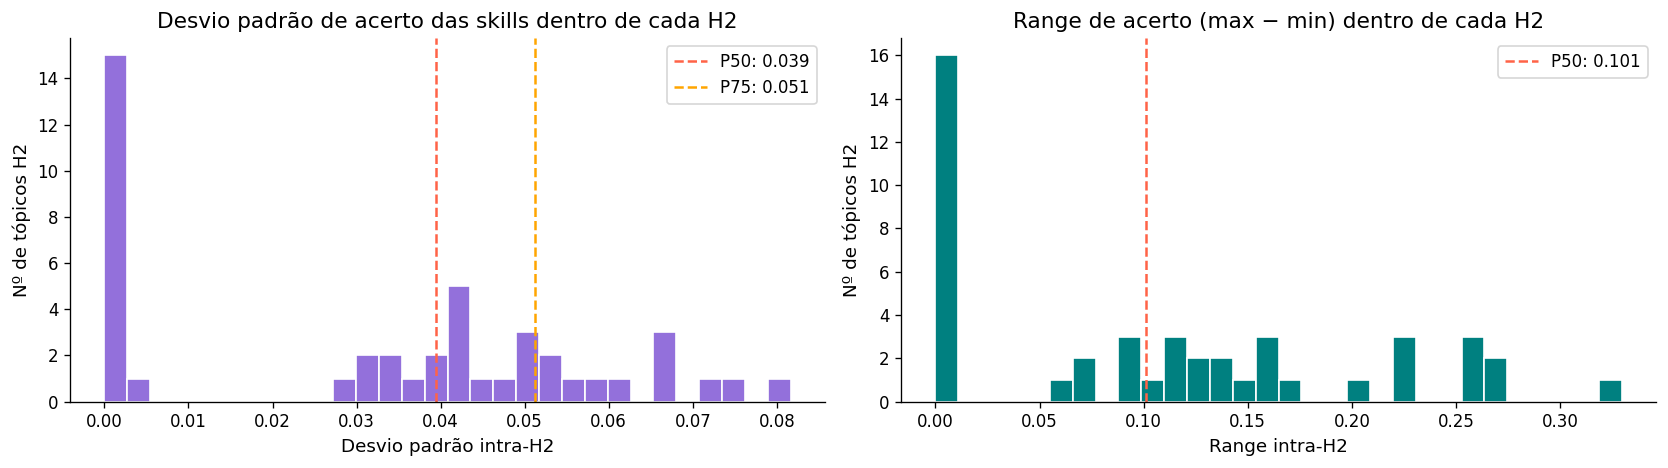

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(intra_h2_stats['intra_std'], bins=30, edgecolor='white', color='mediumpurple')
axes[0].set_title('Desvio padrão de acerto das skills dentro de cada H2')
axes[0].set_xlabel('Desvio padrão intra-H2')
axes[0].set_ylabel('Nº de tópicos H2')
p50 = intra_h2_stats['intra_std'].median()
p75 = intra_h2_stats['intra_std'].quantile(0.75)
axes[0].axvline(p50, color='tomato', linestyle='--', label=f'P50: {p50:.3f}')
axes[0].axvline(p75, color='orange',  linestyle='--', label=f'P75: {p75:.3f}')
axes[0].legend()

axes[1].hist(intra_h2_stats['range'], bins=30, edgecolor='white', color='teal')
axes[1].set_title('Range de acerto (max − min) dentro de cada H2')
axes[1].set_xlabel('Range intra-H2')
axes[1].set_ylabel('Nº de tópicos H2')
p50r = intra_h2_stats['range'].median()
axes[1].axvline(p50r, color='tomato', linestyle='--', label=f'P50: {p50r:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. H2 mais heterogêneos (maior ruído potencial)

Identificamos os tópicos H2 onde a variância intra-grupo é maior, ou seja, onde o colapso introduz mais ruído.

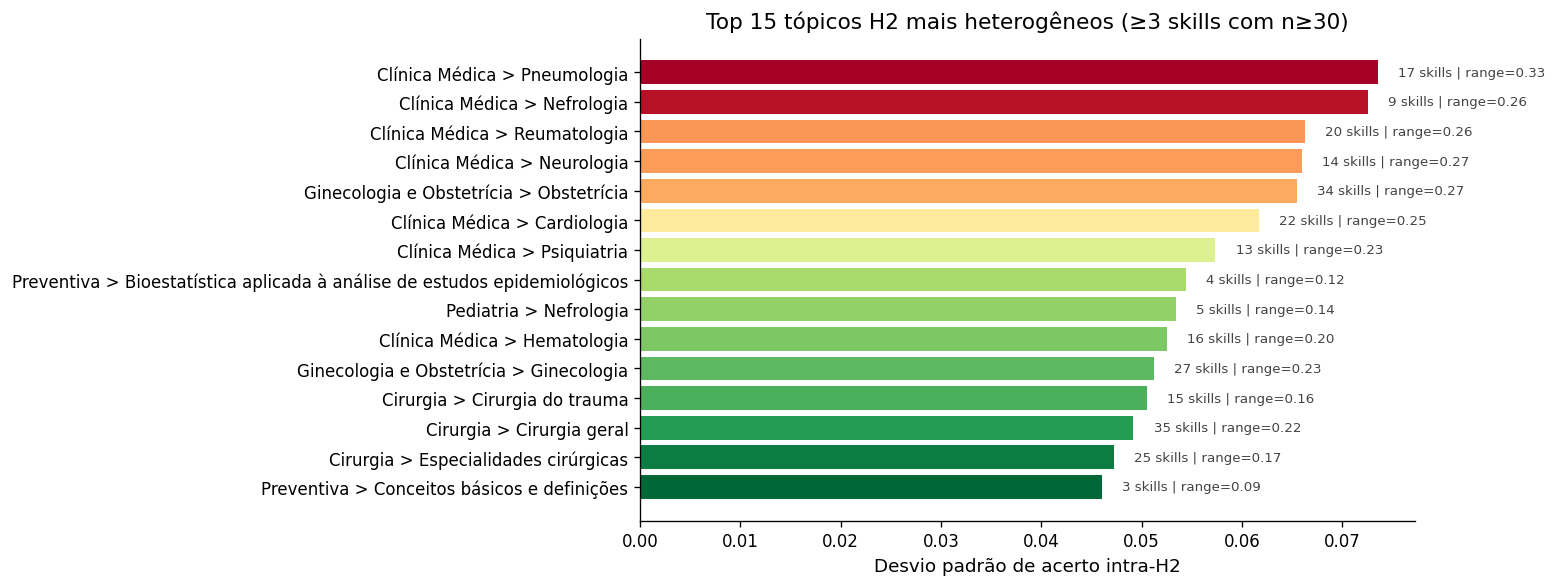

,h2,n_skills,h2_mean_acc,intra_std,min_acc,max_acc,range
0,Clínica Médica > Pneumologia,17,0.6787,0.0736,0.4848,0.8144,0.3296
1,Clínica Médica > Nefrologia,9,0.6614,0.0726,0.5591,0.8207,0.2615
2,Clínica Médica > Reumatologia,20,0.7331,0.0663,0.6481,0.9048,0.2566
3,Clínica Médica > Neurologia,14,0.6978,0.0660,0.4950,0.7632,0.2682
4,Ginecologia e Obstetrícia > Obstetrícia,34,0.7147,0.0655,0.6083,0.8808,0.2725
5,Clínica Médica > Cardiologia,22,0.6753,0.0617,0.5415,0.7958,0.2543
6,Clínica Médica > Psiquiatria,13,0.7496,0.0574,0.6173,0.8438,0.2265
7,Preventiva > Bioestatística aplicada à análise...,4,0.6578,0.0545,0.6177,0.7380,0.1203
8,Pediatria > Nefrologia,5,0.7448,0.0535,0.7030,0.8382,0.1352
9,Clínica Médica > Hematologia,16,0.6853,0.0525,0.5439,0.7445,0.2006


In [8]:
# Top H2 por desvio padrão intra-grupo (mínimo 3 skills para ser relevante)
top_noisy = (
    intra_h2_stats[intra_h2_stats['n_skills'] >= 3]
    .sort_values('intra_std', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))

colors = plt.cm.RdYlGn_r(Normalize()(top_noisy['intra_std']))
bars = ax.barh(top_noisy['h2'], top_noisy['intra_std'], color=colors)

for bar, row in zip(bars, top_noisy.itertuples()):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{row.n_skills} skills | range={row.range:.2f}',
            va='center', fontsize=8, color='#444')

ax.set_xlabel('Desvio padrão de acerto intra-H2')
ax.set_title('Top 15 tópicos H2 mais heterogêneos (≥3 skills com n≥30)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(top_noisy[['h2', 'n_skills', 'h2_mean_acc', 'intra_std', 'min_acc', 'max_acc', 'range']].round(4))

## 7. Drill-down: skills dentro do H2 mais heterogêneo

Para o tópico H2 com maior desvio padrão, inspecionamos o perfil de cada skill individualmente.

H2 mais heterogêneo: "Clínica Médica > Pneumologia"



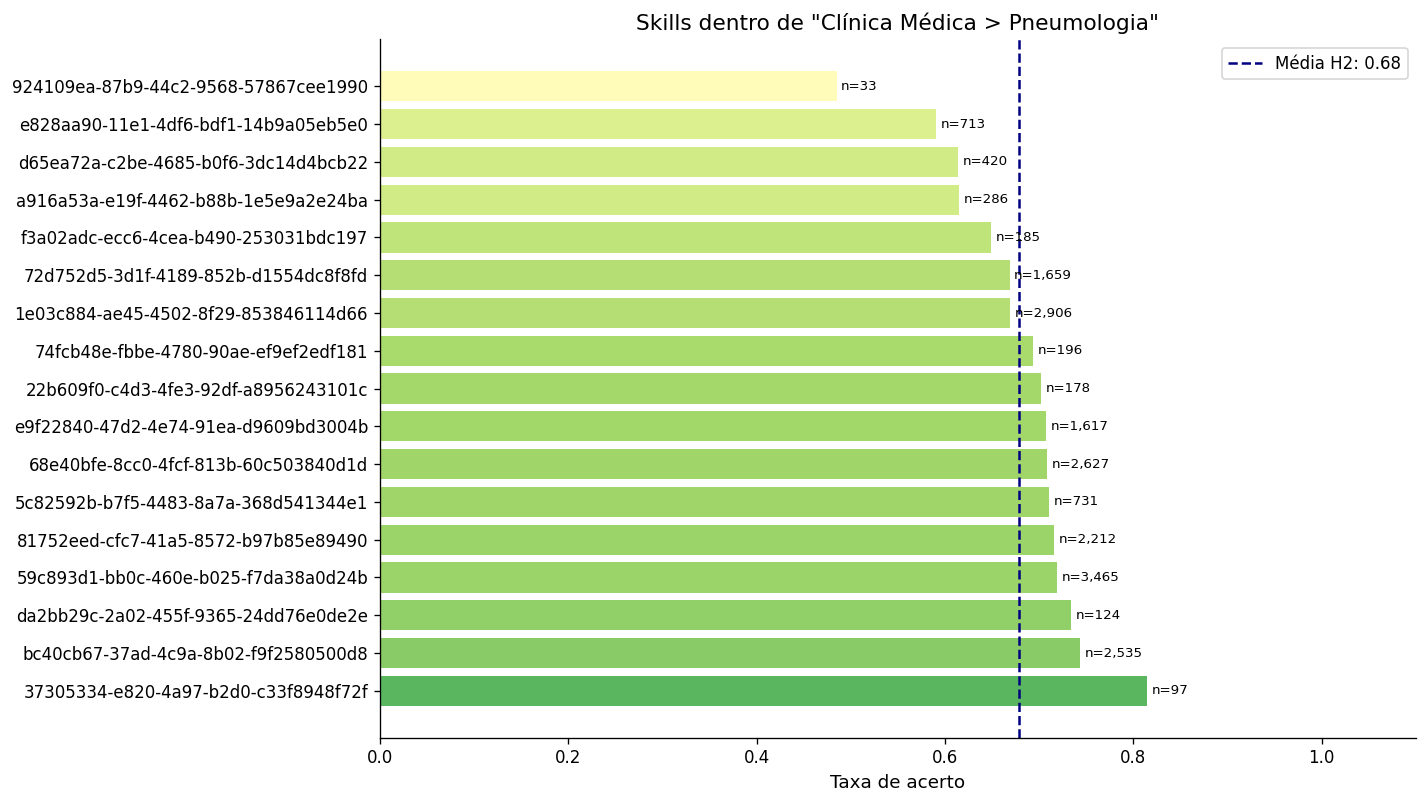

In [9]:
worst_h2 = top_noisy.iloc[0]['h2']
print(f'H2 mais heterogêneo: "{worst_h2}"\n')

worst_skills = skill_acc_with_h2[skill_acc_with_h2['h2'] == worst_h2].sort_values('accuracy')

fig, ax = plt.subplots(figsize=(12, max(3, len(worst_skills) * 0.4)))

colors = plt.cm.RdYlGn(Normalize(vmin=0, vmax=1)(worst_skills['accuracy']))
bars = ax.barh(worst_skills.index.astype(str), worst_skills['accuracy'], color=colors)

for bar, (_, row) in zip(bars, worst_skills.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'n={row["n"]:,.0f}', va='center', fontsize=8)

ax.axvline(worst_skills['accuracy'].mean(), color='navy', linestyle='--',
           label=f'Média H2: {worst_skills["accuracy"].mean():.2f}')
ax.set_xlabel('Taxa de acerto')
ax.set_title(f'Skills dentro de "{worst_h2}"')
ax.set_xlim(0, 1.1)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Estimativa de ruído introduzido pelo colapso H2

Para cada interação, calculamos o erro cometido ao usar a taxa de acerto do H2 como proxy da taxa da skill real.
Esse é o **ruído que o modelo Topic H2 precisa "aprender por cima"** — a diferença entre o que o aluno
deveria ter respondido segundo o H2 e o que a dificuldade real da skill prevê.

MAE do proxy H2 vs skill: 0.0271
P90 do erro              : 0.0539
Interações com erro > 0.1: 1.9%
Interações com erro > 0.2: 0.1%


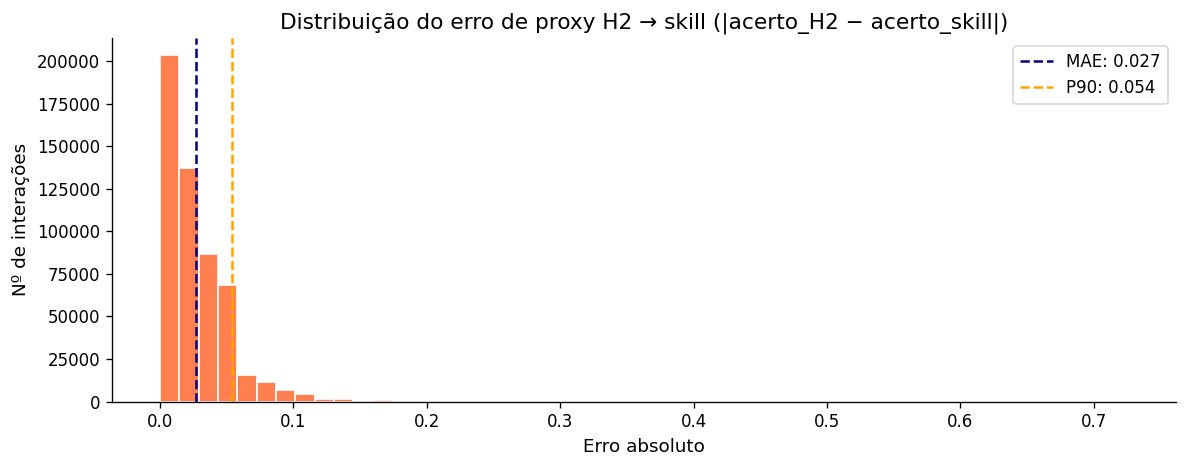

In [10]:
# Mapeia acerto médio por skill e por H2 para cada interação
answers_mapped = answers.dropna(subset=['h2']).copy()
answers_mapped = answers_mapped.merge(
    skill_acc[['accuracy']].rename(columns={'accuracy': 'skill_mean_acc'}),
    left_on='skill_id', right_index=True, how='left'
)
answers_mapped = answers_mapped.merge(
    h2_acc[['accuracy']].rename(columns={'accuracy': 'h2_mean_acc'}),
    left_on='h2', right_index=True, how='left'
)

# Ruído = diferença entre acerto previsto pelo H2 vs pela skill
answers_mapped['proxy_error'] = (
    answers_mapped['h2_mean_acc'] - answers_mapped['skill_mean_acc']
).abs()

mae = answers_mapped['proxy_error'].mean()
p90 = answers_mapped['proxy_error'].quantile(0.9)

print(f'MAE do proxy H2 vs skill: {mae:.4f}')
print(f'P90 do erro              : {p90:.4f}')
print(f'Interações com erro > 0.1: {(answers_mapped["proxy_error"] > 0.1).mean():.1%}')
print(f'Interações com erro > 0.2: {(answers_mapped["proxy_error"] > 0.2).mean():.1%}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(answers_mapped['proxy_error'].dropna(), bins=50, edgecolor='white', color='coral')
ax.axvline(mae, color='navy', linestyle='--', label=f'MAE: {mae:.3f}')
ax.axvline(p90, color='orange', linestyle='--', label=f'P90: {p90:.3f}')
ax.set_title('Distribuição do erro de proxy H2 → skill (|acerto_H2 − acerto_skill|)')
ax.set_xlabel('Erro absoluto')
ax.set_ylabel('Nº de interações')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Correlação entre acerto H2 e acerto skill

Se o H2 for um bom proxy da skill, esperamos alta correlação. Baixa correlação confirma a hipótese de ruído.

Correlação de Pearson (skill_acc vs h2_acc): r = 0.4413


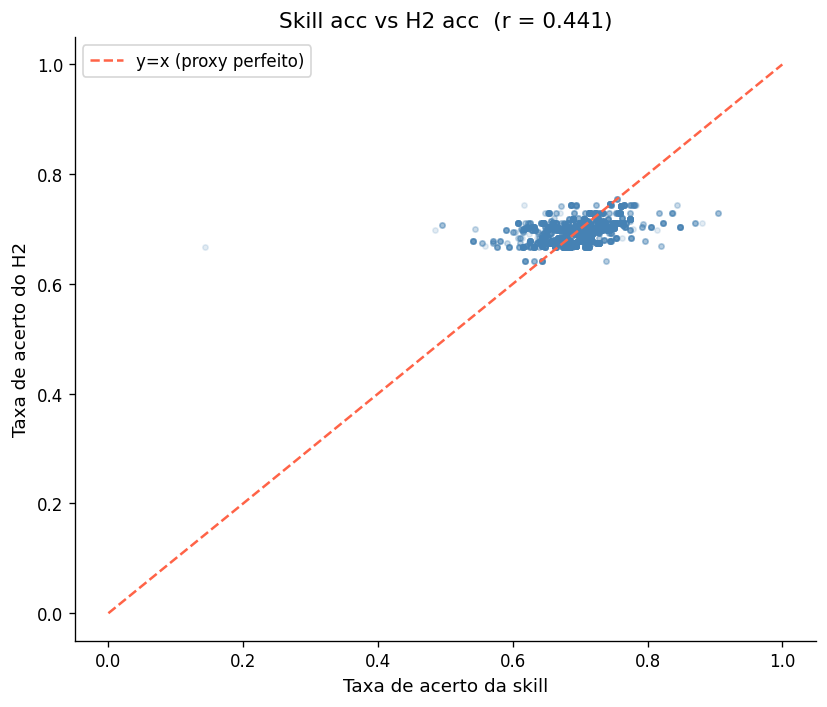

In [11]:
corr_df = answers_mapped.dropna(subset=['skill_mean_acc', 'h2_mean_acc'])

pearson_r = corr_df[['skill_mean_acc', 'h2_mean_acc']].corr().iloc[0, 1]
print(f'Correlação de Pearson (skill_acc vs h2_acc): r = {pearson_r:.4f}')

# Amostragem para o scatter (evita overplot com 500k pontos)
sample = corr_df.sample(min(5000, len(corr_df)), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample['skill_mean_acc'], sample['h2_mean_acc'],
           alpha=0.15, s=10, color='steelblue')
ax.plot([0, 1], [0, 1], color='tomato', linestyle='--', label='y=x (proxy perfeito)')
ax.set_xlabel('Taxa de acerto da skill')
ax.set_ylabel('Taxa de acerto do H2')
ax.set_title(f'Skill acc vs H2 acc  (r = {pearson_r:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Preview: H3 reduziria a variância intra-grupo?

Se usarmos o nível H3 (`names[0] > [1] > [2]`), o agrupamento ficaria mais granular.
Calculamos aqui o desvio intra-grupo esperado para H3 como comparativo.

Tópicos H2 : 45   |  Desvio intra médio: 0.0320
Tópicos H3 : 289   |  Desvio intra médio: 0.0045
Redução de variância intra-grupo com H3: 85.9%


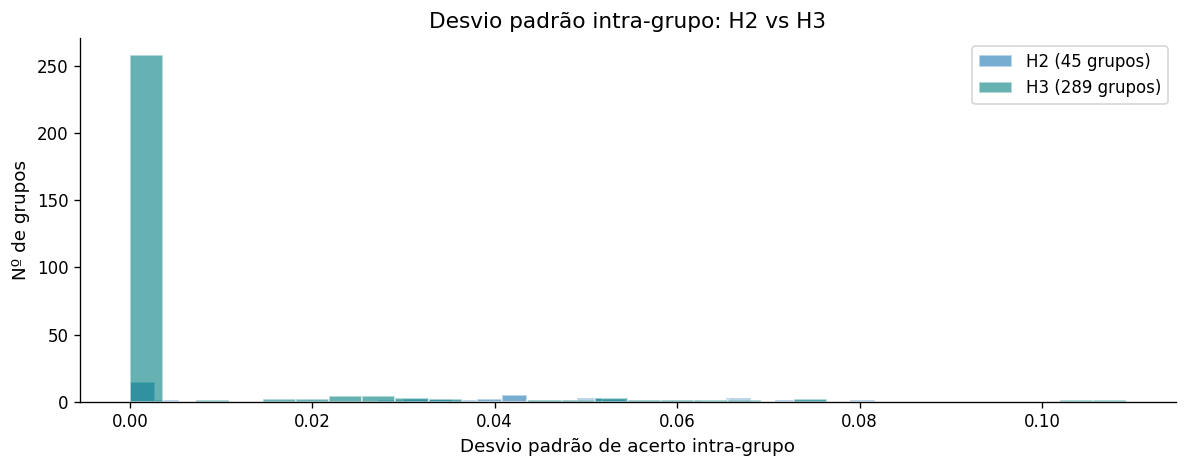

In [12]:
try:
    QUESTIONS_RAW = PROJECT_ROOT / 'data' / 'raw' / 'questions.json'
    try:
        with open(QUESTIONS_RAW, encoding='utf-8') as f:
            questions_raw = json.load(f)
    except UnicodeDecodeError:
        with open(QUESTIONS_RAW, encoding='latin-1') as f:
            questions_raw = json.load(f)

    skill_to_h3: dict[str, str] = {}
    for row in questions_raw:
        sid = row.get('subjectId') or row.get('subject_id')
        names = row.get('subjectAccumulatedNames') or []
        names = [str(x).strip() for x in names if str(x).strip()]
        if sid and len(names) >= 3:
            skill_to_h3[str(sid)] = f"{names[0]} > {names[1]} > {names[2]}"
        elif sid and len(names) >= 2:
            skill_to_h3[str(sid)] = f"{names[0]} > {names[1]}"

    skill_acc_h3 = skill_acc_filtered.copy()
    skill_acc_h3['h3'] = skill_acc_h3.index.map(skill_to_h3)
    skill_acc_h3 = skill_acc_h3.dropna(subset=['h3'])

    intra_h3_std = (
        skill_acc_h3.groupby('h3')['accuracy']
        .std()
        .fillna(0)
    )

    print(f'Tópicos H2 : {len(intra_h2_stats):,}   |  Desvio intra médio: {intra_h2_stats["intra_std"].mean():.4f}')
    print(f'Tópicos H3 : {len(intra_h3_std):,}   |  Desvio intra médio: {intra_h3_std.mean():.4f}')
    print(f'Redução de variância intra-grupo com H3: {1 - intra_h3_std.mean() / intra_h2_stats["intra_std"].mean():.1%}')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(intra_h2_stats['intra_std'], bins=30, alpha=0.6, label=f'H2 ({len(intra_h2_stats)} grupos)', edgecolor='white')
    ax.hist(intra_h3_std,                bins=30, alpha=0.6, label=f'H3 ({len(intra_h3_std)} grupos)',  edgecolor='white', color='teal')
    ax.set_title('Desvio padrão intra-grupo: H2 vs H3')
    ax.set_xlabel('Desvio padrão de acerto intra-grupo')
    ax.set_ylabel('Nº de grupos')
    ax.legend()
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print('questions.json não encontrado em data/raw/ — seção H3 ignorada.')

## 11. Resumo quantitativo

In [13]:
summary = {
    'Skills no dataset'                    : answers['skill_id'].nunique(),
    'Skills mapeadas para H2'              : answers.dropna(subset=['h2'])['skill_id'].nunique(),
    'Interações cobertas por H2'           : f"{answers['h2'].notna().mean():.1%}",
    'Tópicos H2 únicos'                    : answers['h2'].nunique(),
    'Média de skills por H2'               : f"{skills_per_h2.mean():.1f}",
    'Mediana de skills por H2'             : f"{skills_per_h2.median():.0f}",
    'Std de acerto por skill'              : f"{skill_acc_filtered['accuracy'].std():.4f}",
    'Std de acerto por H2'                 : f"{h2_acc['accuracy'].std():.4f}",
    'Compressão de variância (skill→H2)'   : f"{1 - h2_acc['accuracy'].std() / skill_acc_filtered['accuracy'].std():.1%}",
    'MAE proxy H2 vs skill'                : f"{answers_mapped['proxy_error'].mean():.4f}",
    'Interações com erro proxy > 0.1'      : f"{(answers_mapped['proxy_error'] > 0.1).mean():.1%}",
    'Correlação Pearson skill_acc vs H2_acc': f"{pearson_r:.4f}",
}

summary_df = pd.DataFrame(summary.items(), columns=['Métrica', 'Valor'])
print(summary_df.to_string(index=False))

                               Métrica  Valor
                     Skills no dataset    441
               Skills mapeadas para H2    435
            Interações cobertas por H2 100.0%
                     Tópicos H2 únicos     45
                Média de skills por H2    9.7
              Mediana de skills por H2      5
               Std de acerto por skill 0.0562
                  Std de acerto por H2 0.0234
    Compressão de variância (skill→H2)  58.3%
                 MAE proxy H2 vs skill 0.0271
       Interações com erro proxy > 0.1   1.9%
Correlação Pearson skill_acc vs H2_acc 0.4413


## 12. Conclusões e Recomendações

### O que os dados mostram

**Cobertura:** O mapeamento skill → H2 cobre a maior parte das interações. Skills sem mapeamento representam uma fração pequena do total.

**Compressão de variância:** O colapso de skills para H2 comprime significativamente a variância de dificuldade. A distribuição de acerto por skill é muito mais dispersa do que por H2 — confirmando que o agrupamento suaviza o sinal.

**Variância intra-H2:** A maioria dos tópicos H2 contém skills com taxas de acerto heterogêneas. O desvio padrão intra-grupo não é negligenciável, especialmente nos tópicos mais ricos em skills.

**Ruído de proxy:** Para uma fração relevante das interações, a taxa de acerto do H2 diverge da taxa da skill em mais de 0.10 pp. Isso é ruído direto no sinal de supervisionamento dos modelos H2.

**Correlação:** A correlação entre acerto por skill e por H2 indica que o H2 é um proxy imperfeito — há dispersão sistemática ao redor da diagonal.

### Hipótese confirmada?

> **Sim.** A granularidade H2 introduz ruído mensurável. O AUC mais baixo dos modelos Topic H2 (~0.60 vs ~0.68 dos next-item) é parcialmente explicado por esse ruído intra-grupo.

### Recomendações

| Prioridade | Ação | Impacto esperado |
|-----------|------|------------------|
| Alta | Migrar para **H3** (um nível mais profundo) | Reduz variância intra-grupo, melhora sinal |
| Alta | **Filtrar** tópicos H2 com desvio intra > threshold | Remove os grupos mais ruidosos do treino |
| Média | Usar **embedding hierárquico** (skill + H2 + H1) | Modelo aprende granularidade múltipla |
| Média | Ponderar perda por `intra_std` do H2 | Penaliza menos onde o sinal é ambíguo |
| Baixa | Manter H2 só para interpretabilidade pedagógica | Sem alteração no modelo principal |
